# Seren Instances Across Three Energy Days

This notebook compares the same Seren scheduling instances under three representative energy days. The structure is:

1. Shared imports, constants, and energy inputs.
2. Shared solver and decoding functions.
3. Compact comparison for multiple instances.
4. A small visual check for the tiny instance.

The notebook uses only the node-based formulation:

- `Gurobi_node`: classical MILP with real renewable/grid dispatch.
- `QUBO_node`: D-Wave simulated annealing over the node-unit QUBO.

Block-mode QUBO is intentionally excluded here to keep the comparison focused and readable.


## 1. Shared Imports and Configuration


In [1]:
from __future__ import annotations

import time
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import ipywidgets as widgets
from dwave.samplers import SimulatedAnnealingSampler

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelConfig
from src.data.energy_prices import load_marginalpdbc
from src.data.gpu_unit_adapter import adapt_gpu_unit
from src.data.scenarios import ENERGY_SCENARIOS
from src.data.solar_profiles import build_daily_hourly_solar_profile
from src.milp.solve import solve_model
from src.milp.gurobi_model import build_milp_model
from src.quantum.qubo_builder import (
    QuboPenaltyWeights,
    build_scheduling_qubo,
    decode_qubo_sample,
    to_dimod_bqm,
    validate_decoded_schedule,
)

INSTANCE_ROOT = PROJECT_ROOT / "data" / "instances" / "seren_pretrain"
SOLAR_PATH = PROJECT_ROOT / "data" / "energy" / "solar" / "Timeseries_40.409_-3.698_SA3_1000kWp_crystSi_14_36deg_-5deg_2020_2023.csv"
PRICE_COLUMN = "last"
PUE = 1.25
MIN_LOAD_FRACTION = 0.10
TIME_LIMIT_SECONDS = 60
MIP_GAP = 0.001
QUBO_NUM_READS = 1000
QUBO_RANDOM_SEED = 123

INSTANCE_NAMES = [
    "tiny_6_jobs",
    "avg_active_day_jobs",
    "small_12_jobs",
    "medium_24_jobs",
    "max_day_jobs",
]


Matplotlib created a temporary cache directory at /var/folders/kj/srm136c14rq3h_h76tdm02700000gn/T/matplotlib-i3xasoxv because the default path (/Users/juanparrado/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Shared Data Loading

All instances are Seren pretraining workloads. The model uses node units, so each job's GPU requirement is expressed as number of 8-GPU A100 nodes. We do not display the original GPU grouping columns here because this notebook is focused on the scheduling comparison, not trace preprocessing.


In [2]:
def load_instance(instance_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load one Seren instance and convert GPU requirements to node units."""

    instance_dir = INSTANCE_ROOT / instance_name
    jobs_raw = pd.read_csv(instance_dir / "jobs.csv")
    clusters_raw = pd.read_csv(instance_dir / "clusters.csv")
    jobs_df, clusters_df = adapt_gpu_unit(jobs_raw, clusters_raw, "node")  # type: ignore[arg-type]
    jobs_df["cpu_required"] = jobs_df.get("cpu_required", 0.0).fillna(0.0)
    jobs_df["memory_required_gb"] = jobs_df.get("memory_required_gb", 0.0).fillna(0.0)
    return jobs_df, clusters_df


def compact_instance_summary(instance_name: str) -> dict:
    """Return compact workload-size metrics for one instance."""

    jobs_df, clusters_df = load_instance(instance_name)
    start_options = jobs_df["latest_start"] - jobs_df["earliest_start"] + 1
    return {
        "instance": instance_name,
        "jobs": len(jobs_df),
        "avg_start_options": float(start_options.mean()),
        "total_node_hours": float((jobs_df["gpu_count_required"] * jobs_df["duration"]).sum()),
        "max_nodes_per_job": float(jobs_df["gpu_count_required"].max()),
        "cluster_node_capacity": float(clusters_df["gpu_count"].sum()),
        "it_energy_mwh_if_run_once": float((jobs_df["power"] * jobs_df["duration"]).sum()),
    }

instance_summary_df = pd.DataFrame([compact_instance_summary(name) for name in INSTANCE_NAMES])
instance_summary_df.round(4)


,instance,jobs,avg_start_options,total_node_hours,max_nodes_per_job,cluster_node_capacity,it_energy_mwh_if_run_once
0,tiny_6_jobs,6,4.1667,48.0,8.0,286.0,0.1536
1,avg_active_day_jobs,8,3.8750,302.0,96.0,286.0,0.9664
2,small_12_jobs,12,3.5000,356.0,64.0,286.0,1.1392
3,medium_24_jobs,24,4.0833,744.0,96.0,286.0,2.3808
4,max_day_jobs,65,3.7846,2101.0,120.0,286.0,6.7232


## 3. Shared Energy Days

The grid price comes from the day-ahead marginal price files. Solar availability comes from the repository PVGIS 1000 kWp profile. Renewable price is currently a placeholder set at 80% of the minimum grid price for the selected day.


In [3]:
def build_energy_day(scenario_name: str, scenario: dict) -> pd.DataFrame:
    """Build one 24-hour energy table from grid price and PVGIS solar."""

    price_df = load_marginalpdbc(PROJECT_ROOT / scenario["price_file"], price_column=PRICE_COLUMN)
    solar_df = build_daily_hourly_solar_profile(SOLAR_PATH, scenario["date"])
    hourly = price_df[["hour", "grid_price"]].merge(
        solar_df[["hour", "renewable_available"]],
        on="hour",
        how="inner",
        validate="one_to_one",
    )
    hourly["pue"] = PUE
    hourly["baseline_load"] = 0.0
    hourly["renewable_price"] = 0.8 * float(hourly["grid_price"].min())
    hourly["scenario"] = scenario_name
    hourly["date"] = scenario["date"]
    return hourly[["scenario", "date", "hour", "renewable_available", "grid_price", "renewable_price", "pue", "baseline_load"]]

energy_days = {name: build_energy_day(name, scenario) for name, scenario in ENERGY_SCENARIOS.items()}
energy_summary_df = pd.DataFrame([
    {
        "scenario": name,
        "date": df["date"].iloc[0],
        "min_grid_price": df["grid_price"].min(),
        "mean_grid_price": df["grid_price"].mean(),
        "max_grid_price": df["grid_price"].max(),
        "renewable_price": df["renewable_price"].iloc[0],
        "total_renewable_mwh": df["renewable_available"].sum(),
        "max_renewable_mw": df["renewable_available"].max(),
    }
    for name, df in energy_days.items()
]).sort_values("date")
energy_summary_df.round(4)


,scenario,date,min_grid_price,mean_grid_price,max_grid_price,renewable_price,total_renewable_mwh,max_renewable_mw
0,clear_sky,2023-04-04,8.00,56.2054,106.14,6.400,6.5620,0.8925
1,overcast,2023-06-07,65.70,87.1600,107.36,52.560,1.0555,0.2104
2,base,2023-09-27,77.14,114.8346,170.00,61.712,5.0676,0.7053


## 4. Shared Solver Helpers

The QUBO does not explicitly decide renewable/grid dispatch. It uses an instance-specific `effective_price` as a proxy. After solving, both Gurobi and QUBO schedules are decoded using the same real dispatch rule so the comparison is fair.


In [4]:
def expected_load_scale_mw(
    jobs_df: pd.DataFrame,
    clusters_df: pd.DataFrame,
    hourly_df: pd.DataFrame,
    *,
    pue: float,
    min_load_fraction: float = MIN_LOAD_FRACTION,
) -> float:
    """Compute the instance-specific facility load scale used by QUBO."""

    horizon_slots = len(hourly_df)
    average_facility_load = pue * float((jobs_df["power"] * jobs_df["duration"]).sum()) / float(horizon_slots)
    cluster_floor = min_load_fraction * float(clusters_df["capacity"].sum()) * pue
    return max(average_facility_load, cluster_floor)


def add_effective_price_for_qubo(
    hourly_df: pd.DataFrame,
    jobs_df: pd.DataFrame,
    clusters_df: pd.DataFrame,
) -> pd.DataFrame:
    """Add instance-specific renewable share and effective price columns."""

    out = hourly_df.copy()
    load_scale = expected_load_scale_mw(jobs_df, clusters_df, hourly_df, pue=float(out["pue"].iloc[0]))
    out["expected_load_scale_mw"] = load_scale
    out["renewable_share"] = (out["renewable_available"] / load_scale).clip(lower=0.0, upper=1.0)
    out["effective_price"] = (
        out["renewable_share"] * out["renewable_price"]
        + (1.0 - out["renewable_share"]) * out["grid_price"]
    )
    return out


def make_qubo_hourly_inputs(energy_df: pd.DataFrame) -> pd.DataFrame:
    """Convert rich energy inputs into reduced QUBO hourly inputs."""

    return pd.DataFrame({
        "hour": energy_df["hour"].astype(int),
        "renewable_available": 0.0,
        "grid_price": energy_df["effective_price"].astype(float),
        "pue": energy_df["pue"].astype(float),
        "baseline_load": 0.0,
    })


def compute_schedule_dispatch_profile(
    schedule: pd.DataFrame,
    energy_df: pd.DataFrame,
    *,
    pue: float,
    delta_t: float = 1.0,
) -> pd.DataFrame:
    """Compute realized grid/renewable dispatch and cost from a fixed schedule."""

    rows = []
    for energy_row in energy_df.sort_values("hour").itertuples(index=False):
        hour = int(energy_row.hour)
        active = schedule[(schedule["start_hour"] <= hour) & (hour < schedule["start_hour"] + schedule["duration"])]
        it_load_mw = float(active["power"].sum()) if not active.empty else 0.0
        facility_load_mw = pue * it_load_mw
        renewable_available_mw = float(energy_row.renewable_available)
        renewable_price = float(energy_row.renewable_price)
        grid_price = float(energy_row.grid_price)

        if renewable_price <= grid_price:
            renewable_used_mw = min(facility_load_mw, renewable_available_mw)
        else:
            renewable_used_mw = 0.0
        grid_used_mw = max(facility_load_mw - renewable_used_mw, 0.0)
        effective_price = float(getattr(energy_row, "effective_price", grid_price))

        rows.append({
            "hour": hour,
            "it_load_mw": it_load_mw,
            "facility_load_mw": facility_load_mw,
            "renewable_available_mw": renewable_available_mw,
            "renewable_used_mw": renewable_used_mw,
            "grid_used_mw": grid_used_mw,
            "grid_price": grid_price,
            "renewable_price": renewable_price,
            "effective_price": effective_price,
            "real_dispatch_cost": delta_t * (renewable_price * renewable_used_mw + grid_price * grid_used_mw),
            "effective_price_proxy_cost": delta_t * facility_load_mw * effective_price,
        })
    return pd.DataFrame(rows)


def summarize_schedule_cost(schedule: pd.DataFrame, energy_df: pd.DataFrame, *, pue: float, delta_t: float = 1.0) -> dict:
    """Summarize comparable cost and energy metrics for a decoded schedule."""

    if schedule.empty:
        return {
            "real_dispatch_energy_cost": None,
            "effective_price_proxy_cost": None,
            "facility_energy_mwh": None,
            "renewable_energy_mwh": None,
            "grid_energy_mwh": None,
            "peak_facility_load_mw": None,
        }
    profile = compute_schedule_dispatch_profile(schedule, energy_df, pue=pue, delta_t=delta_t)
    return {
        "real_dispatch_energy_cost": float(profile["real_dispatch_cost"].sum()),
        "effective_price_proxy_cost": float(profile["effective_price_proxy_cost"].sum()),
        "facility_energy_mwh": float((profile["facility_load_mw"] * delta_t).sum()),
        "renewable_energy_mwh": float((profile["renewable_used_mw"] * delta_t).sum()),
        "grid_energy_mwh": float((profile["grid_used_mw"] * delta_t).sum()),
        "peak_facility_load_mw": float(profile["facility_load_mw"].max()),
    }


In [5]:
def summarize_schedule_violations(violations: list[str]) -> str:
    """Compress detailed validation messages into a short reason string."""

    if not violations:
        return ""
    categories = []
    if any("expected" in message and "assigned jobs" in message for message in violations):
        categories.append("wrong_assignment_count")
    if any("missing jobs" in message for message in violations):
        categories.append("missing_jobs")
    if any("duplicated jobs" in message for message in violations):
        categories.append("duplicated_jobs")
    if any("outside its window" in message for message in violations):
        categories.append("start_window")
    if any("incompatible cluster" in message for message in violations):
        categories.append("compatibility")
    if any("exceeds gpu capacity" in message for message in violations):
        categories.append("gpu_capacity")
    if any("exceeds cpu capacity" in message for message in violations):
        categories.append("cpu_capacity")
    if any("exceeds memory capacity" in message for message in violations):
        categories.append("memory_capacity")
    if not categories:
        categories.append("other")
    return ", ".join(categories)


def audit_qubo_constraints(
    qubo,
    sample: dict[int, int] | None,
    schedule: pd.DataFrame,
    jobs_df: pd.DataFrame,
    clusters_df: pd.DataFrame,
    hours: list[int],
) -> dict:
    """Audit decoded QUBO schedule constraints and sampled slack-bit consistency."""

    if sample is None:
        return {
            "schedule_constraints_feasible": False,
            "schedule_violation_count": None,
            "schedule_violation_summary": "no_sample",
            "schedule_violations": "no sample returned",
            "slack_consistent": None,
            "slack_violation_count": None,
            "max_slack_residual": None,
        }

    schedule_validation = validate_decoded_schedule(schedule, jobs_df, clusters_df, hours)
    violations = schedule_validation["violations"]
    cluster_capacity = clusters_df.set_index("cluster_id")["gpu_count"].astype(float).to_dict()
    gpu_load = {(str(cluster_id), int(hour)): 0.0 for cluster_id in cluster_capacity for hour in hours}

    for row in schedule.itertuples(index=False):
        for hour in hours:
            if int(row.start_hour) <= int(hour) < int(row.start_hour) + int(row.duration):
                gpu_load[(str(row.assigned_cluster), int(hour))] += float(row.gpu_count_required)

    slack_value: dict[tuple[str, int], float] = {}
    for index, variable in enumerate(qubo.variables):
        if variable.get("variable_type") != "gpu_slack":
            continue
        key = (str(variable["cluster"]), int(variable["hour"]))
        slack_value[key] = slack_value.get(key, 0.0) + float(variable["coefficient"]) * int(sample.get(index, 0))

    residuals = []
    for key, slack in slack_value.items():
        cluster_id, _ = key
        residuals.append(gpu_load.get(key, 0.0) + slack - float(cluster_capacity[cluster_id]))

    slack_violations = [residual for residual in residuals if abs(residual) > 1e-8]
    return {
        "schedule_constraints_feasible": bool(schedule_validation["feasible"]),
        "schedule_violation_count": len(violations),
        "schedule_violation_summary": summarize_schedule_violations(violations),
        "schedule_violations": "; ".join(violations),
        "slack_consistent": len(slack_violations) == 0,
        "slack_violation_count": len(slack_violations),
        "max_slack_residual": max((abs(residual) for residual in residuals), default=0.0),
    }


def solve_gurobi_node(instance_name: str, scenario_name: str, energy_df: pd.DataFrame, jobs_df: pd.DataFrame, clusters_df: pd.DataFrame) -> dict:
    """Solve one instance/scenario with Gurobi using node units."""

    hourly_df = energy_df[["hour", "renewable_available", "grid_price", "pue", "baseline_load"]].copy()
    facility_capacity_mw = float(clusters_df["capacity"].sum()) * float(hourly_df["pue"].iloc[0])
    config = ModelConfig(
        contracted_power=facility_capacity_mw,
        renewable_price=float(energy_df["renewable_price"].iloc[0]),
        peak_price=1000.0,
        delta_t=1.0,
        pue=float(hourly_df["pue"].iloc[0]),
    )
    start_time = time.perf_counter()
    model, variables = build_milp_model(
        jobs_df,
        hourly_df,
        clusters_df,
        config,
        model_name=f"seren_{instance_name}_{scenario_name}_node",
        enforce_gpu_constraints=True,
        enforce_cpu_constraints=False,
        enforce_memory_constraints=False,
    )
    model.Params.OutputFlag = 0
    solve_model(model, time_limit=TIME_LIMIT_SECONDS, mip_gap=MIP_GAP)
    runtime_s = time.perf_counter() - start_time

    schedule_rows = []
    if model.SolCount:
        for (job_id, cluster, start), var in variables["x"].items():
            if var.X > 0.5:
                job = jobs_df.loc[jobs_df["job_id"] == job_id].iloc[0]
                schedule_rows.append({
                    "job_id": job_id,
                    "assigned_cluster": cluster,
                    "start_hour": int(start),
                    "duration": int(job["duration"]),
                    "end_hour": int(start + job["duration"]),
                    "power": float(job["power"]),
                    "gpu_count_required": float(job["gpu_count_required"]),
                    "cpu_required": float(job.get("cpu_required", 0.0)),
                    "memory_required_gb": float(job.get("memory_required_gb", 0.0)),
                })
    schedule = pd.DataFrame(schedule_rows).sort_values(["start_hour", "job_id"]).reset_index(drop=True)
    cost_summary = summarize_schedule_cost(schedule, energy_df, pue=float(energy_df["pue"].iloc[0]))
    return {
        "instance": instance_name,
        "scenario": scenario_name,
        "solver": "Gurobi_node",
        "feasible": bool(model.SolCount),
        "assigned_jobs": len(schedule),
        "runtime_s": runtime_s,
        "mip_gap": model.MIPGap if model.SolCount else None,
        "gurobi_objective": model.ObjVal if model.SolCount else None,
        "qubo_hamiltonian_energy": None,
        "num_variables": None,
        "assignment_variables": None,
        "slack_variables": None,
        "quadratic_terms": None,
        "schedule_constraints_feasible": bool(model.SolCount),
        "schedule_violation_count": 0 if model.SolCount else None,
        "schedule_violation_summary": "",
        "schedule_violations": "",
        "slack_consistent": None,
        "slack_violation_count": None,
        "max_slack_residual": None,
        "schedule": schedule,
        "energy_actual": energy_df,
        **cost_summary,
    }


def solve_qubo_node(instance_name: str, scenario_name: str, energy_df: pd.DataFrame, jobs_df: pd.DataFrame, clusters_df: pd.DataFrame) -> dict:
    """Build, sample, and decode one node-unit QUBO for an instance/scenario.

    If no feasible decoded schedule is found, the function still returns the
    lowest-Hamiltonian decoded sample so we can inspect why it failed and compare
    its raw load/cost profile against Gurobi. In that case `feasible=False` and
    the decoded cost is diagnostic, not a valid schedule cost.
    """

    hourly_qubo = make_qubo_hourly_inputs(energy_df)
    config = ModelConfig(
        contracted_power=float(clusters_df["capacity"].sum()) * float(hourly_qubo["pue"].iloc[0]),
        renewable_price=1e9,
        peak_price=1000.0,
        delta_t=1.0,
        pue=float(hourly_qubo["pue"].iloc[0]),
    )
    start_time = time.perf_counter()
    qubo = build_scheduling_qubo(
        jobs_df,
        hourly_qubo,
        clusters_df,
        config,
        QuboPenaltyWeights(assignment=1000.0, gpu_capacity=100.0, peak_smoothing=0.0),
    )
    sampleset = SimulatedAnnealingSampler().sample(
        to_dimod_bqm(qubo),
        num_reads=QUBO_NUM_READS,
        seed=QUBO_RANDOM_SEED,
    )
    runtime_s = time.perf_counter() - start_time
    hours = [int(hour) for hour in hourly_qubo["hour"].tolist()]

    best_raw_schedule = pd.DataFrame()
    best_raw_energy = None
    best_raw_sample = None
    best_feasible_schedule = pd.DataFrame()
    best_feasible_energy = None
    best_feasible_sample = None

    for position, (sample, energy) in enumerate(sampleset.data(["sample", "energy"])):
        schedule = decode_qubo_sample(qubo, sample)
        sample_dict = {int(index): int(value) for index, value in sample.items()}
        if position == 0:
            best_raw_schedule = schedule
            best_raw_energy = float(energy)
            best_raw_sample = sample_dict
        validation = validate_decoded_schedule(schedule, jobs_df, clusters_df, hours)
        if validation["feasible"]:
            best_feasible_schedule = schedule
            best_feasible_energy = float(energy)
            best_feasible_sample = sample_dict
            break

    using_feasible_sample = best_feasible_sample is not None
    selected_schedule = best_feasible_schedule if using_feasible_sample else best_raw_schedule
    selected_energy = best_feasible_energy if using_feasible_sample else best_raw_energy
    selected_sample = best_feasible_sample if using_feasible_sample else best_raw_sample
    if not selected_schedule.empty:
        selected_schedule = selected_schedule.assign(end_hour=lambda x: x["start_hour"] + x["duration"])

    cost_summary = summarize_schedule_cost(selected_schedule, energy_df, pue=float(energy_df["pue"].iloc[0]))
    constraint_audit = audit_qubo_constraints(qubo, selected_sample, selected_schedule, jobs_df, clusters_df, hours)
    return {
        "instance": instance_name,
        "scenario": scenario_name,
        "solver": "QUBO_node",
        "feasible": bool(using_feasible_sample),
        "assigned_jobs": len(selected_schedule),
        "runtime_s": runtime_s,
        "mip_gap": None,
        "gurobi_objective": None,
        "qubo_hamiltonian_energy": selected_energy,
        "num_variables": qubo.num_variables,
        "assignment_variables": qubo.metadata["num_assignment_variables"],
        "slack_variables": qubo.metadata["num_slack_variables"],
        "quadratic_terms": qubo.metadata["num_quadratic_terms"],
        "schedule": selected_schedule,
        "energy_actual": energy_df,
        **constraint_audit,
        **cost_summary,
    }


## 5. Run All Instances

For every instance and energy day we solve:

- Gurobi with real renewable/grid dispatch.
- QUBO node mode with effective price, then decoded under the same real dispatch rule.

The output intentionally keeps only metrics needed to compare solution quality, feasibility, and QUBO size.


In [6]:
def solve_instance_across_energy_days(instance_name: str) -> list[dict]:
    """Solve one instance across all configured energy days."""

    jobs_df, clusters_df = load_instance(instance_name)
    results = []
    for scenario_name, base_energy_df in energy_days.items():
        energy_df = add_effective_price_for_qubo(base_energy_df, jobs_df, clusters_df)
        results.append(solve_gurobi_node(instance_name, scenario_name, energy_df, jobs_df, clusters_df))
        results.append(solve_qubo_node(instance_name, scenario_name, energy_df, jobs_df, clusters_df))
    return results

all_results = []
for instance_name in INSTANCE_NAMES:
    all_results.extend(solve_instance_across_energy_days(instance_name))

comparison_columns = [
    "instance",
    "scenario",
    "solver",
    "feasible",
    "assigned_jobs",
    "real_dispatch_energy_cost",
    "facility_energy_mwh",
    "renewable_energy_mwh",
    "grid_energy_mwh",
    "peak_facility_load_mw",
    "runtime_s",
    "mip_gap",
    "num_variables",
    "assignment_variables",
    "slack_variables",
    "quadratic_terms",
    "schedule_constraints_feasible",
    "schedule_violation_count",
    "schedule_violation_summary",
    "schedule_violations",
    "slack_consistent",
    "slack_violation_count",
    "max_slack_residual",
]
comparison_df = pd.DataFrame([{col: result.get(col) for col in comparison_columns} for result in all_results])
print(
    f"Solved {len(INSTANCE_NAMES)} instances across {len(energy_days)} energy days: "
    f"{len(comparison_df)} solver runs."
)
print(
    "QUBO feasible runs: "
    f"{int(((comparison_df['solver'] == 'QUBO_node') & comparison_df['feasible']).sum())} / "
    f"{int((comparison_df['solver'] == 'QUBO_node').sum())}"
)


Set parameter Username


Set parameter LicenseID to value 2828833


Academic license - for non-commercial use only - expires 2027-05-29


Solved 5 instances across 3 energy days: 30 solver runs.
QUBO feasible runs: 4 / 15


## 6. Per-Instance Compact Results

Each table has one row per energy day. The core comparison is `real_dispatch_energy_cost`: this is computed from the decoded schedule using the same real grid/renewable dispatch rule for both solvers.

`QUBO_feasible = False` means the sampler did not return a schedule assigning every job exactly once while respecting the scheduling constraints. The QUBO size columns are still reported because they are useful for understanding when the formulation becomes hard.


In [7]:
def compact_instance_result(instance_name: str) -> pd.DataFrame:
    """Build a compact Gurobi-vs-QUBO summary for one instance."""

    energy_cost_table = comparison_df.pivot_table(
        index=["instance", "scenario"],
        columns="solver",
        values="real_dispatch_energy_cost",
        aggfunc="first",
    ).reset_index()
    energy_cost_table = energy_cost_table[energy_cost_table["instance"] == instance_name].copy()
    energy_cost_table["qubo_minus_gurobi"] = energy_cost_table["QUBO_node"] - energy_cost_table["Gurobi_node"]
    energy_cost_table["qubo_gap_pct"] = 100.0 * energy_cost_table["qubo_minus_gurobi"] / energy_cost_table["Gurobi_node"].replace(0, np.nan)

    qubo_rows = comparison_df[(comparison_df["instance"] == instance_name) & (comparison_df["solver"] == "QUBO_node")][[
        "scenario",
        "feasible",
        "num_variables",
        "assignment_variables",
        "slack_variables",
        "quadratic_terms",
        "schedule_constraints_feasible",
        "schedule_violation_summary",
        "slack_consistent",
        "runtime_s",
    ]].rename(columns={
        "feasible": "QUBO_feasible",
        "runtime_s": "QUBO_runtime_s",
    })

    out = energy_cost_table.merge(qubo_rows, on="scenario", how="left")
    columns = [
        "scenario",
        "Gurobi_node",
        "QUBO_node",
        "qubo_gap_pct",
        "QUBO_feasible",
        "num_variables",
        "assignment_variables",
        "slack_variables",
        "quadratic_terms",
        "schedule_constraints_feasible",
        "schedule_violation_summary",
        "slack_consistent",
        "QUBO_runtime_s",
    ]
    return out[columns].sort_values("scenario").round(4)

for instance_name in INSTANCE_NAMES:
    print(f"\n{instance_name}")
    display(compact_instance_result(instance_name))



tiny_6_jobs


,scenario,Gurobi_node,QUBO_node,qubo_gap_pct,QUBO_feasible,num_variables,assignment_variables,slack_variables,quadratic_terms,schedule_constraints_feasible,schedule_violation_summary,slack_consistent,QUBO_runtime_s
0,base,11.8487,11.8487,-0.0000,True,97.0,25.0,72.0,595.0,True,,True,0.8980
1,clear_sky,1.2288,1.2288,0.0000,True,97.0,25.0,72.0,595.0,True,,True,0.9160
2,overcast,10.0915,11.9072,17.9925,True,97.0,25.0,72.0,595.0,True,,True,0.9021



avg_active_day_jobs


,scenario,Gurobi_node,QUBO_node,qubo_gap_pct,QUBO_feasible,num_variables,assignment_variables,slack_variables,quadratic_terms,schedule_constraints_feasible,schedule_violation_summary,slack_consistent,QUBO_runtime_s
0,base,74.5481,90.6950,21.6597,False,148.0,31.0,117.0,820.0,False,"wrong_assignment_count, duplicated_jobs",False,1.3720
1,clear_sky,7.7312,18.4303,138.3883,False,148.0,31.0,117.0,820.0,False,"wrong_assignment_count, duplicated_jobs",False,1.3476
2,overcast,82.8516,95.5680,15.3484,True,148.0,31.0,117.0,820.0,True,,False,1.3228



small_12_jobs


,scenario,Gurobi_node,QUBO_node,qubo_gap_pct,QUBO_feasible,num_variables,assignment_variables,slack_variables,quadratic_terms,schedule_constraints_feasible,schedule_violation_summary,slack_consistent,QUBO_runtime_s
0,base,135.7467,185.8171,36.8852,False,240.0,42.0,198.0,1253.0,False,"wrong_assignment_count, duplicated_jobs",False,2.1279
1,clear_sky,58.6947,95.5418,62.7776,False,240.0,42.0,198.0,1253.0,False,"wrong_assignment_count, duplicated_jobs",False,2.0922
2,overcast,111.4285,116.5762,4.6197,False,240.0,42.0,198.0,1253.0,False,"wrong_assignment_count, missing_jobs",False,2.1390



medium_24_jobs


,scenario,Gurobi_node,QUBO_node,qubo_gap_pct,QUBO_feasible,num_variables,assignment_variables,slack_variables,quadratic_terms,schedule_constraints_feasible,schedule_violation_summary,slack_consistent,QUBO_runtime_s
0,base,205.8348,354.0928,72.0276,False,287.0,98.0,189.0,2031.0,False,"wrong_assignment_count, missing_jobs, duplicat...",False,2.8504
1,clear_sky,42.2422,126.6114,199.7271,False,287.0,98.0,189.0,2031.0,False,"wrong_assignment_count, missing_jobs, duplicat...",False,2.8689
2,overcast,211.4765,289.2666,36.7843,False,287.0,98.0,189.0,2031.0,False,"wrong_assignment_count, missing_jobs, duplicat...",False,2.8202



max_day_jobs


,scenario,Gurobi_node,QUBO_node,qubo_gap_pct,QUBO_feasible,num_variables,assignment_variables,slack_variables,quadratic_terms,schedule_constraints_feasible,schedule_violation_summary,slack_consistent,QUBO_runtime_s
0,base,727.2394,1044.6618,43.6476,False,444.0,246.0,198.0,5426.0,False,"wrong_assignment_count, missing_jobs, duplicat...",False,5.8904
1,clear_sky,178.9529,408.1490,128.0762,False,444.0,246.0,198.0,5426.0,False,"wrong_assignment_count, missing_jobs, duplicat...",False,5.8450
2,overcast,702.0354,794.4763,13.1676,False,444.0,246.0,198.0,5426.0,False,"wrong_assignment_count, missing_jobs, duplicat...",False,5.8194


## 7. Per-Instance Visual Comparison

Each subplot corresponds to one instance type. Bars compare realized energy cost after decoding the schedule with the same renewable/grid dispatch rule. A red cross means QUBO did not return a feasible decoded schedule for that scenario.


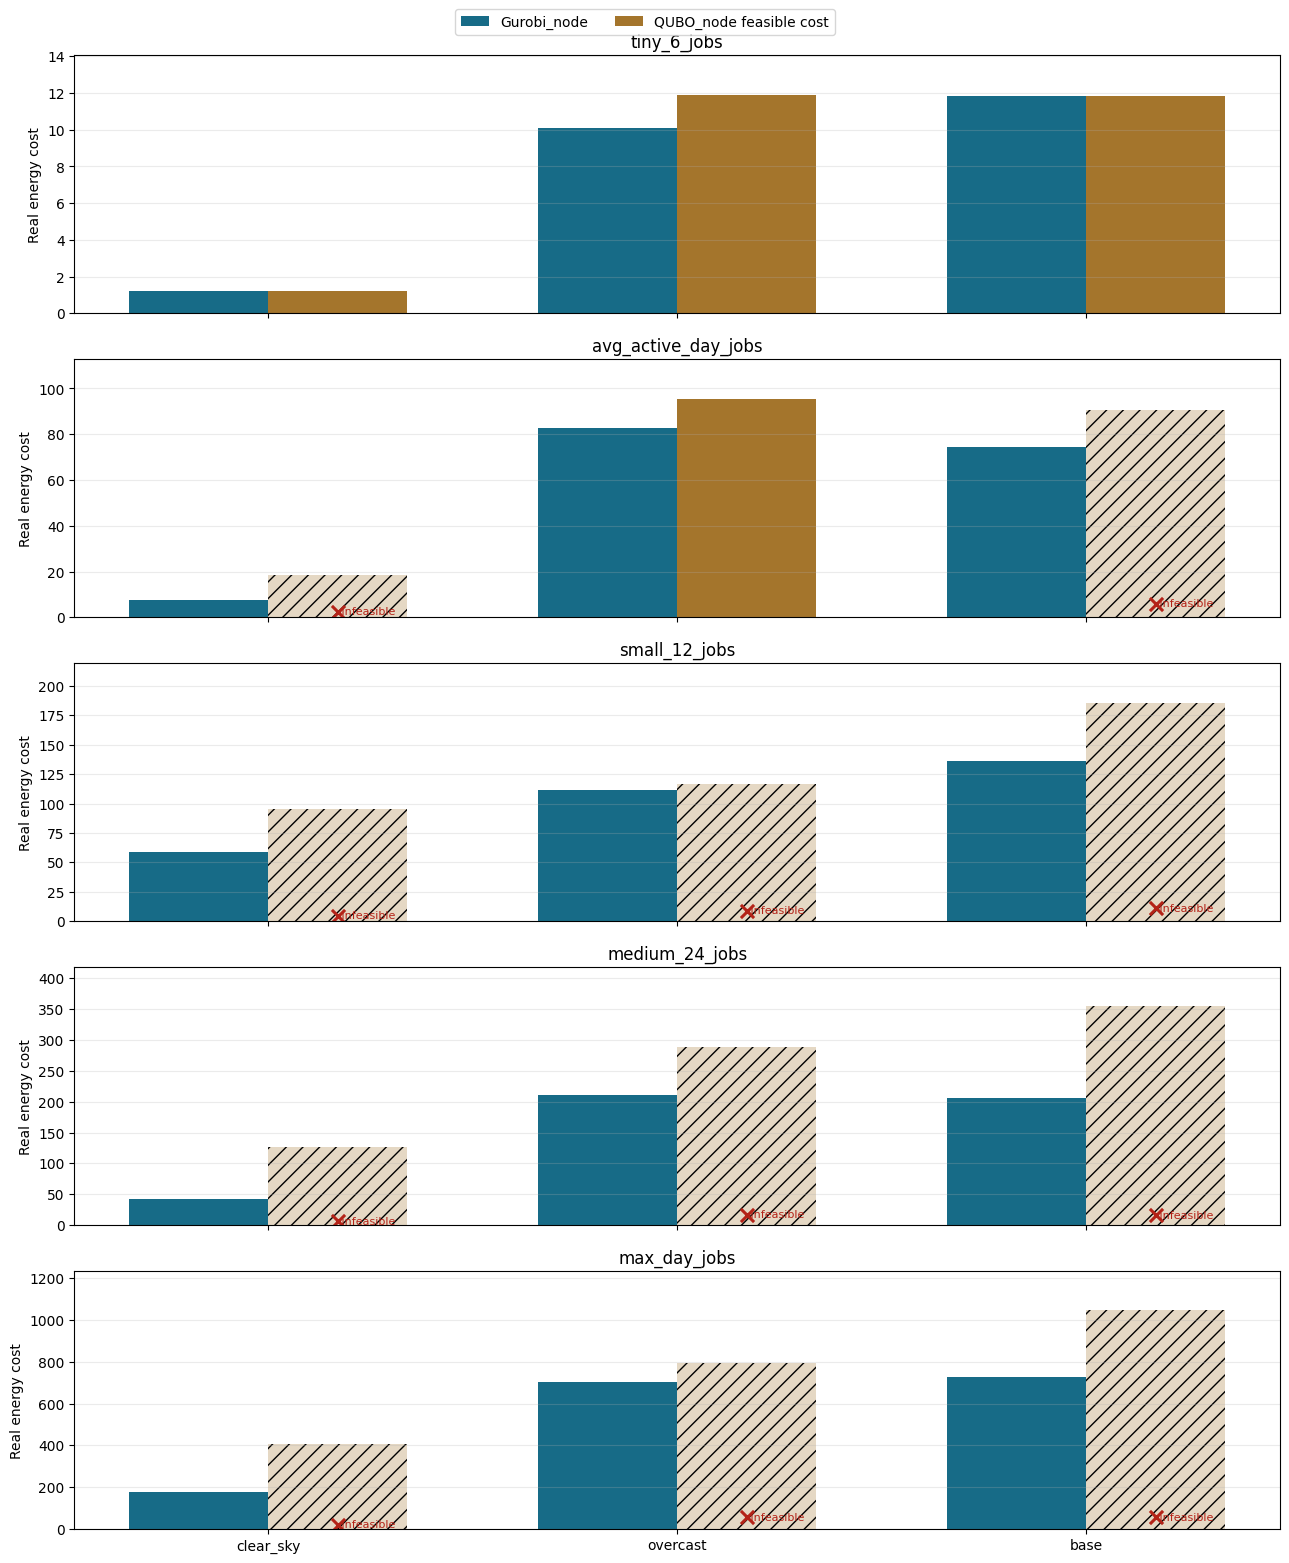

In [8]:
scenario_order = list(energy_days.keys())
fig, axes = plt.subplots(len(INSTANCE_NAMES), 1, figsize=(13, 3.1 * len(INSTANCE_NAMES)), sharex=True)
if len(INSTANCE_NAMES) == 1:
    axes = [axes]

for ax, instance_name in zip(axes, INSTANCE_NAMES):
    visual_df = compact_instance_result(instance_name).set_index("scenario").reindex(scenario_order).reset_index()
    x = np.arange(len(scenario_order))
    width = 0.34

    gurobi_values = visual_df["Gurobi_node"].astype(float).to_numpy()
    qubo_values = visual_df["QUBO_node"].astype(float).to_numpy()
    qubo_feasible = visual_df["QUBO_feasible"].fillna(False).astype(bool).to_numpy()

    ax.bar(x - width / 2, gurobi_values, width, label="Gurobi_node", color="#176b87")

    for idx, feasible in enumerate(qubo_feasible):
        qubo_height = 0.0 if np.isnan(qubo_values[idx]) else qubo_values[idx]
        ax.bar(
            x[idx] + width / 2,
            qubo_height,
            width,
            label="QUBO_node feasible cost" if idx == 0 else None,
            color="#9a6615",
            alpha=0.9 if feasible else 0.25,
            hatch=None if feasible else "//",
        )
        if not feasible:
            marker_y = max(gurobi_values[idx] * 0.08, max(gurobi_values) * 0.03)
            ax.scatter(x[idx] + width / 2, marker_y, marker="x", s=90, color="#b42318", linewidth=2.2)
            ax.text(
                x[idx] + width / 2,
                marker_y,
                " infeasible",
                color="#b42318",
                va="center",
                ha="left",
                fontsize=8,
            )

    ax.set_title(instance_name)
    ax.set_ylabel("Real energy cost")
    ax.grid(axis="y", alpha=0.25)
    ax.margins(y=0.18)

axes[-1].set_xticks(np.arange(len(scenario_order)))
axes[-1].set_xticklabels(scenario_order)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout()
plt.show()


## 8. QUBO Size Summary

This table isolates the QUBO size and feasibility audit. It is the main reference for deciding which instances are realistic candidates for D-Wave, Fujitsu Digital Annealer, QAOA slicing, Pauli Correlation Encoding, or tensor-network experiments.


In [9]:
qubo_size_audit_table = comparison_df[comparison_df["solver"] == "QUBO_node"][[
    "instance",
    "scenario",
    "feasible",
    "assigned_jobs",
    "num_variables",
    "assignment_variables",
    "slack_variables",
    "quadratic_terms",
    "schedule_constraints_feasible",
    "schedule_violation_count",
    "schedule_violation_summary",
    "slack_consistent",
    "slack_violation_count",
    "max_slack_residual",
    "runtime_s",
]].sort_values(["instance", "scenario"])
qubo_size_audit_table.round(4)


,instance,scenario,feasible,assigned_jobs,num_variables,assignment_variables,slack_variables,quadratic_terms,schedule_constraints_feasible,schedule_violation_count,schedule_violation_summary,slack_consistent,slack_violation_count,max_slack_residual,runtime_s
11,avg_active_day_jobs,base,False,9,148.0,31.0,117.0,820.0,False,2,"wrong_assignment_count, duplicated_jobs",False,1.0,2.0,1.3720
7,avg_active_day_jobs,clear_sky,False,10,148.0,31.0,117.0,820.0,False,2,"wrong_assignment_count, duplicated_jobs",False,2.0,1.0,1.3476
9,avg_active_day_jobs,overcast,True,8,148.0,31.0,117.0,820.0,True,0,,False,10.0,2.0,1.3228
29,max_day_jobs,base,False,84,444.0,246.0,198.0,5426.0,False,3,"wrong_assignment_count, missing_jobs, duplicat...",False,4.0,1.0,5.8904
25,max_day_jobs,clear_sky,False,85,444.0,246.0,198.0,5426.0,False,3,"wrong_assignment_count, missing_jobs, duplicat...",False,7.0,2.0,5.8450
27,max_day_jobs,overcast,False,80,444.0,246.0,198.0,5426.0,False,3,"wrong_assignment_count, missing_jobs, duplicat...",False,6.0,2.0,5.8194
23,medium_24_jobs,base,False,31,287.0,98.0,189.0,2031.0,False,3,"wrong_assignment_count, missing_jobs, duplicat...",False,7.0,3.0,2.8504
19,medium_24_jobs,clear_sky,False,28,287.0,98.0,189.0,2031.0,False,3,"wrong_assignment_count, missing_jobs, duplicat...",False,6.0,2.0,2.8689
21,medium_24_jobs,overcast,False,28,287.0,98.0,189.0,2031.0,False,3,"wrong_assignment_count, missing_jobs, duplicat...",False,7.0,2.0,2.8202
17,small_12_jobs,base,False,15,240.0,42.0,198.0,1253.0,False,2,"wrong_assignment_count, duplicated_jobs",False,5.0,2.0,2.1279


## 9. Interactive Schedule Visual Check

Use the selector to inspect any instance type. The plot shows the decoded Gurobi and QUBO schedules for each energy day. If QUBO did not find a feasible schedule, its decoded best sample is still plotted with a dashed line and an `infeasible` label, so we can inspect what the sampler produced.


In [10]:
def schedule_load_profile(schedule: pd.DataFrame, energy_df: pd.DataFrame, pue: float) -> pd.DataFrame:
    """Compute IT and facility load for a decoded schedule."""

    rows = []
    for hour in energy_df["hour"].astype(int).tolist():
        active = schedule[(schedule["start_hour"] <= hour) & (hour < schedule["start_hour"] + schedule["duration"])]
        it_load = float(active["power"].sum()) if not active.empty else 0.0
        rows.append({"hour": hour, "it_load_mw": it_load, "facility_load_mw": pue * it_load})
    return pd.DataFrame(rows)


def plot_instance_schedule(instance_name: str) -> None:
    """Plot decoded schedules for one instance across the three energy days."""

    fig, axes = plt.subplots(len(energy_days), 1, figsize=(14, 10), sharex=True)
    if len(energy_days) == 1:
        axes = [axes]

    for ax, scenario_name in zip(axes, energy_days):
        ax2 = ax.twinx()
        scenario_results = [
            result for result in all_results
            if result["instance"] == instance_name and result["scenario"] == scenario_name
        ]
        energy_df = scenario_results[0]["energy_actual"]
        for result, color in zip(scenario_results, ["#176b87", "#9a6615"]):
            profile = schedule_load_profile(
                result["schedule"],
                result["energy_actual"],
                pue=float(result["energy_actual"]["pue"].iloc[0]),
            )
            is_valid = bool(result["schedule_constraints_feasible"])
            label = result["solver"] if is_valid else f"{result['solver']} decoded infeasible"
            ax.step(
                profile["hour"],
                profile["facility_load_mw"],
                where="mid",
                linewidth=2.0,
                color=color,
                linestyle="-" if is_valid else "--",
                alpha=0.95 if is_valid else 0.65,
                label=label,
            )
        qubo_result = next(result for result in scenario_results if result["solver"] == "QUBO_node")
        if not qubo_result["schedule_constraints_feasible"]:
            ax.text(
                0.01,
                0.88,
                f"QUBO infeasible: {qubo_result['schedule_violation_summary']}",
                transform=ax.transAxes,
                color="#b42318",
                fontsize=9,
                bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "#b42318"},
            )

        ax.bar(energy_df["hour"], energy_df["renewable_available"], color="#f2b84b", alpha=0.25, label="renewable available")
        ax2.plot(energy_df["hour"], energy_df["grid_price"], color="#111111", marker="o", linewidth=1.4, label="grid price")
        ax2.plot(energy_df["hour"], energy_df["effective_price"], color="#2c7a57", marker="x", linewidth=1.4, label="QUBO effective price")
        ax.set_title(f"{instance_name} - {scenario_name} ({energy_df['date'].iloc[0]})")
        ax.set_ylabel("Power (MW)")
        ax2.set_ylabel("Price")
        ax.grid(alpha=0.25)
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", ncol=2, fontsize=8)

    axes[-1].set_xlabel("Hour")
    axes[-1].set_xticks(range(24))
    plt.tight_layout()
    plt.show()


instance_selector = widgets.Dropdown(
    options=INSTANCE_NAMES,
    value="tiny_6_jobs",
    description="Instance:",
    layout=widgets.Layout(width="360px"),
)
interactive_plot = widgets.interactive_output(plot_instance_schedule, {"instance_name": instance_selector})
display(widgets.VBox([instance_selector, interactive_plot]))


## 10. Reading the Results

Use `real_dispatch_energy_cost` for the fair Gurobi vs QUBO comparison only when `schedule_constraints_feasible=True`. When QUBO is infeasible, this value is still shown as the cost of the decoded best sample, but it is diagnostic rather than a valid schedule cost.

Use QUBO size metrics to decide which instances are realistic for quantum experiments:

- `num_variables`: binary variables required by the QUBO.
- `assignment_variables`: job-start assignment decisions.
- `slack_variables`: unused-capacity bits for GPU capacity constraints.
- `quadratic_terms`: couplers/interactions in the QUBO.

Use the constraint audit columns to understand QUBO failures. `schedule_violation_summary` explains the main reason the decoded sample is infeasible, such as missing jobs, duplicated jobs, start-window violations, compatibility violations, or GPU-capacity violations. Slack inconsistency means the sampled slack bits are not perfectly encoded; it can inflate Hamiltonian energy but does not necessarily invalidate the decoded schedule if `schedule_constraints_feasible` remains true.
